PARTE 1. PRIORIZANDO HIPÓTESES

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from statsmodels.stats.proportion import proportions_ztest
from scipy.stats import mannwhitneyu

hypotheses = pd.read_csv('/datasets/hypotheses_us.csv', sep = ';')
orders = pd.read_csv('/datasets/orders_us.csv', sep = ';')
visits = pd.read_csv('/datasets/visits_us.csv', sep = ';')
print(hypotheses.head())
print()
print(orders.head())
print()
print(visits.head())

                                          Hypothesis  Reach  Impact  \
0  Add two new channels for attracting traffic. T...      3      10   
1  Launch your own delivery service. This will sh...      2       5   
2  Add product recommendation blocks to the store...      8       3   
3  Change the category structure. This will incre...      8       3   
4  Change the background color on the main page. ...      3       1   

   Confidence  Effort  
0           8       6  
1           4      10  
2           7       3  
3           3       8  
4           1       1  

  transactionId,visitorId,date,revenue,group
0    3667963787,3312258926,2019-08-15,30.4,B
1    2804400009,3642806036,2019-08-15,15.2,B
2    2961555356,4069496402,2019-08-15,10.2,A
3   3797467345,1196621759,2019-08-15,155.1,B
4    2282983706,2322279887,2019-08-15,40.5,B

  date,group,visits
0  2019-08-01,A,719
1  2019-08-02,A,619
2  2019-08-03,A,507
3  2019-08-04,A,717
4  2019-08-05,A,756


In [34]:
#Código ajustado pela revisora - Perceba que os outros dataframes carregam normalmente sem o uso do argumento `sep`

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from statsmodels.stats.proportion import proportions_ztest
from scipy.stats import mannwhitneyu

hypotheses = pd.read_csv('/datasets/hypotheses_us.csv', sep = ';')
orders = pd.read_csv('/datasets/orders_us.csv')
visits = pd.read_csv('/datasets/visits_us.csv')
print(hypotheses.head())
print()
print(orders.head())
print()
print(visits.head())

                                          Hypothesis  Reach  Impact  \
0  Add two new channels for attracting traffic. T...      3      10   
1  Launch your own delivery service. This will sh...      2       5   
2  Add product recommendation blocks to the store...      8       3   
3  Change the category structure. This will incre...      8       3   
4  Change the background color on the main page. ...      3       1   

   Confidence  Effort  
0           8       6  
1           4      10  
2           7       3  
3           3       8  
4           1       1  

   transactionId   visitorId        date  revenue group
0     3667963787  3312258926  2019-08-15     30.4     B
1     2804400009  3642806036  2019-08-15     15.2     B
2     2961555356  4069496402  2019-08-15     10.2     A
3     3797467345  1196621759  2019-08-15    155.1     B
4     2282983706  2322279887  2019-08-15     40.5     B

         date group  visits
0  2019-08-01     A     719
1  2019-08-02     A     619
2  2019

In [35]:
#hypotheses.columns = hypotheses.columns.str.lower().str.strip()
hypotheses['date'] = pd.to_datetime(hypotheses['date'], errors='coerce')


KeyError: 'date'

<div class="alert alert-block alert-danger">
  <b>Comentário:</b> <a class="tocSkip"></a>
    
O erro ocorre porque o dataset foi carregado com o separador incorreto. O arquivo utiliza `;` como delimitador, mas o read_csv do pandas, por padrão, assume ,. Como consequência, todas as colunas foram lidas como uma única coluna, o que gera o `KeyError` ao tentar acessar impact, confidence e effort.

Dica de como resolver:

- Recarregar o arquivo utilizando o parâmetro correto:

```pd.read_csv('arquivo.csv', sep=';')```


<div class="alert alert-block alert-danger">
  <b>Comentário v2:</b> <a class="tocSkip"></a>
    
O erro acima ainda continou pois não há coluna `date` no dataframe de hyphotheses. 

In [36]:
hypotheses.info()
hypotheses.isna().sum()
print()
orders.info()
orders.isna().sum()
print()
visits.info()
visits.isna().sum()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9 entries, 0 to 8
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Hypothesis  9 non-null      object
 1   Reach       9 non-null      int64 
 2   Impact      9 non-null      int64 
 3   Confidence  9 non-null      int64 
 4   Effort      9 non-null      int64 
dtypes: int64(4), object(1)
memory usage: 488.0+ bytes

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1197 entries, 0 to 1196
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   transactionId  1197 non-null   int64  
 1   visitorId      1197 non-null   int64  
 2   date           1197 non-null   object 
 3   revenue        1197 non-null   float64
 4   group          1197 non-null   object 
dtypes: float64(1), int64(2), object(2)
memory usage: 46.9+ KB

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 62 entries, 0 to 61
Data columns (to

date      0
group     0
visits    0
dtype: int64

In [37]:
orders['date'] = pd.to_datetime(orders['date'], errors='coerce')
orders['revenue'] = pd.to_numeric(orders['revenue'], errors='coerce')

visits['date'] = pd.to_datetime(visits['date'], errors='coerce')





In [38]:
hypotheses = hypotheses.drop_duplicates()
orders = orders.drop_duplicates()
visits = visits.drop_duplicates()

In [39]:
users_multiple_groups = (
    orders.groupby('visitorId')['group']
    .nunique()
    .reset_index()
)

users_multiple_groups = users_multiple_groups[
    users_multiple_groups['group'] > 1
]


In [40]:
bad_users = users_multiple_groups['visitorId']

orders_clean = orders[~orders['visitorId'].isin(bad_users)]


In [41]:
# Separar a coluna única em múltiplas colunas
# hypotheses = hypotheses['Hypothesis;Reach;Impact;Confidence;Effort'].str.split(';', expand=True)

# # Definir os nomes das colunas
# hypotheses.columns = ['Hypothesis', 'Reach', 'Impact', 'Confidence', 'Effort']

# Verificar o resultado
print(hypotheses.head())

                                          Hypothesis  Reach  Impact  \
0  Add two new channels for attracting traffic. T...      3      10   
1  Launch your own delivery service. This will sh...      2       5   
2  Add product recommendation blocks to the store...      8       3   
3  Change the category structure. This will incre...      8       3   
4  Change the background color on the main page. ...      3       1   

   Confidence  Effort  
0           8       6  
1           4      10  
2           7       3  
3           3       8  
4           1       1  


In [42]:
cols_numericas = ['Impact', 'Confidence', 'Effort']
for col in cols_numericas:
    hypotheses[col] = pd.to_numeric(hypotheses[col], errors='coerce')

# Remover hipóteses com dados inválidos
hypotheses = hypotheses.dropna(subset=cols_numericas)

# Aplicar ICE para cada hipótese
hypotheses['ICE'] = (hypotheses['Impact'] * hypotheses['Confidence']) / hypotheses['Effort']

# Ordenar as hipóteses por prioridade (ICE decrescente)
hypotheses_priorizadas = hypotheses.sort_values(by='ICE', ascending=False)

# Exibir resultado final
print(hypotheses_priorizadas[['Hypothesis', 'ICE']])


                                          Hypothesis        ICE
8  Launch a promotion that gives users discounts ...  16.200000
0  Add two new channels for attracting traffic. T...  13.333333
7  Add a subscription form to all the main pages....  11.200000
6  Show banners with current offers and sales on ...   8.000000
2  Add product recommendation blocks to the store...   7.000000
1  Launch your own delivery service. This will sh...   2.000000
5  Add a customer review page. This will increase...   1.333333
3  Change the category structure. This will incre...   1.125000
4  Change the background color on the main page. ...   1.000000


In [43]:
cols_numericas = ['Reach', 'Impact', 'Confidence', 'Effort']
for col in cols_numericas:
    hypotheses[col] = pd.to_numeric(hypotheses[col], errors='coerce')

In [44]:
# Aplicar RICE para cada hipótese
hypotheses['RICE'] = (
    hypotheses['Reach'] *
    hypotheses['Impact'] *
    hypotheses['Confidence']
) / hypotheses['Effort']

# Ordenar as hipóteses por prioridade (RICE decrescente)
hypotheses_priorizadas = hypotheses.sort_values(by='RICE', ascending=False)

# Exibir resultado final
print(hypotheses_priorizadas[['Hypothesis', 'RICE']])

                                          Hypothesis   RICE
7  Add a subscription form to all the main pages....  112.0
2  Add product recommendation blocks to the store...   56.0
0  Add two new channels for attracting traffic. T...   40.0
6  Show banners with current offers and sales on ...   40.0
8  Launch a promotion that gives users discounts ...   16.2
3  Change the category structure. This will incre...    9.0
1  Launch your own delivery service. This will sh...    4.0
5  Add a customer review page. This will increase...    4.0
4  Change the background color on the main page. ...    3.0


<div class="alert alert-block alert-success">
  <b>Comentário v2:</b> <a class="tocSkip"></a>

RICE calculado com sucesso

A principal diferença entre o RICE e o ICE é a inclusção do alcance, ou seja, quantas pessoas vão ser impactadas no teste. A inclusão favorece testes que atingem muitos usuários e é execelente para lidar com crescimento em escala e decisões mais estratégicas. Já o Ice funciona melhor para times pequenos e experimentos curtos e rápidos.

PARTE 2. ANÁLISE DE TESTE A/B

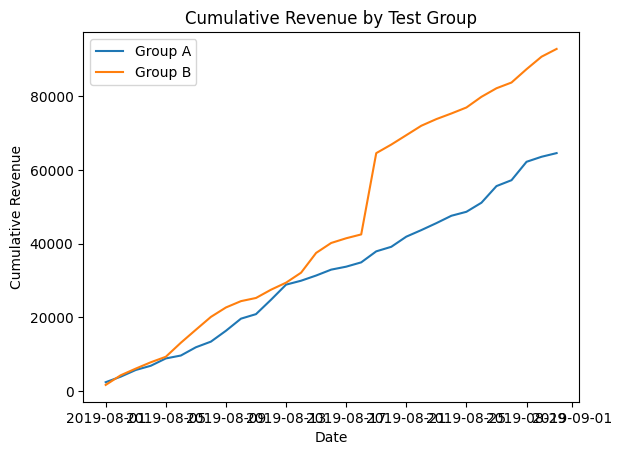

In [45]:
# Receita diária por grupo
daily_revenue = (
    orders
    .groupby(['date', 'group'], as_index=False)
    .agg({'revenue': 'sum'})
)

# Receita acumulada por grupo
daily_revenue = daily_revenue.sort_values('date')
daily_revenue['cumulative_revenue'] = (
    daily_revenue
    .groupby('group')['revenue']
    .cumsum()
)

# Gráfico
plt.figure()
for group in daily_revenue['group'].unique():
    data = daily_revenue[daily_revenue['group'] == group]
    plt.plot(data['date'], data['cumulative_revenue'], label=f'Group {group}')

plt.xlabel('Date')
plt.ylabel('Cumulative Revenue')
plt.title('Cumulative Revenue by Test Group')
plt.legend()
plt.show()

Ambos os grupos apresentam crescimento consistente de receita ao longo do tempo, o que indica:

- tráfego estável
 - ausência de problemas graves de coleta de dados

O grupo A cresce de forma mais estável

A curva do grupo A é mais suave e menor variância → comportamento mais previsível, porém, com menor resultado total.

O grupo B ultrapassa o grupo A e mantém uma distância crescente até o final do período e gera mais receita acumulada como aponta
a curva. Há um momento que existe um crescimento abrupto do grupo B o que pode indicar:

 - pedidos de alto valor
 - ou poucos usuários com receitas muito acima da média

Um alerta. O padrão também sugere uma presença de usuários anomalos no grupo B.


Hipótese 1 — Valor médio do pedido (AOV) maior no grupo B

Mesmo com conversões similares, o grupo B pode estar:

incentivando compras maiores e impactando mix de produtos mais caros

 - Isso precisaria ser confirmado analisando receita média por pedido.

Hipótese 2 — Usuários anômalos distorcendo a receita do grupo B

O salto abrupto indica:

poucos pedidos muito altos

risco de falso positivo se analisarmos apenas receita acumulada

 - Remover usuários com muitos pedidos ou pedidos muito caros e refazer a análise.

Hipótese 3 — Efeito real da variação B

Se, após remover anomalias:

o grupo B continuar superior e a diferença for estatisticamente significativa

 - Então há evidência forte para implementar a variação B.

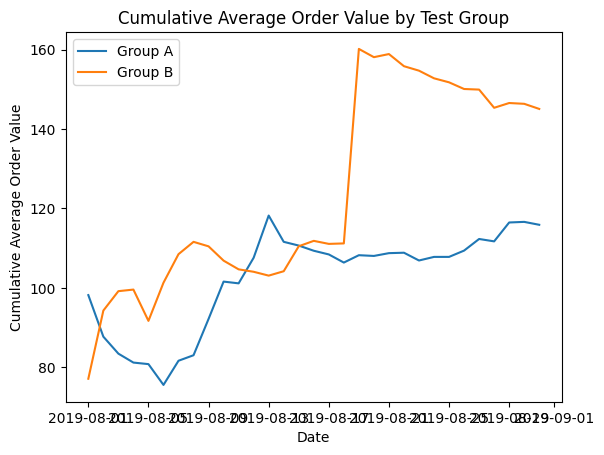

In [46]:
# Métricas diárias por grupo
daily_metrics = (
    orders
    .groupby(['date', 'group'], as_index=False)
    .agg(
        daily_revenue=('revenue', 'sum'),
        daily_orders=('transactionId', 'nunique')
    )
)

# Ordenar e calcular acumulados
daily_metrics = daily_metrics.sort_values('date')
daily_metrics['cum_revenue'] = daily_metrics.groupby('group')['daily_revenue'].cumsum()
daily_metrics['cum_orders'] = daily_metrics.groupby('group')['daily_orders'].cumsum()

# Tamanho médio acumulado do pedido (AOV)
daily_metrics['cum_avg_order_value'] = (
    daily_metrics['cum_revenue'] / daily_metrics['cum_orders']
)

# Gráfico
plt.figure()
for group in daily_metrics['group'].unique():
    data = daily_metrics[daily_metrics['group'] == group]
    plt.plot(data['date'], data['cum_avg_order_value'], label=f'Group {group}')

plt.xlabel('Date')
plt.ylabel('Cumulative Average Order Value')
plt.title('Cumulative Average Order Value by Test Group')
plt.legend()
plt.show()

Como vimos no gráfico anterior o grupo B apresenta um resultado AOV acumulado maior e o grupo á é mais estável.

O aumento repentino no grupo B não é tipico de melhorias graduais de ex ou pricing, o que levanta suspeitas.

Hipótese 1 — Usuários anômalos no grupo B

Poucos pedidos de valor muito alto estão:

inflando o AOV e puxando a receita acumulada do grupo B

 - Isso é muito comum nesse dataset e precisa ser tratado antes da decisão final.

Hipótese 2 — A variação B incentiva compras maiores

Se, após remover outliers:

o AOV do grupo B continuar maior e a diferença for estatisticamente significativa

 - Então a variação B realmente aumenta o valor do pedido, não apenas a conversão.

🔸 Hipótese 3 — Risco de falso positivo

Sem tratamento de anomalias:

o grupo B parece vencedor mas a decisão pode estar baseada em poucos usuários atípicos

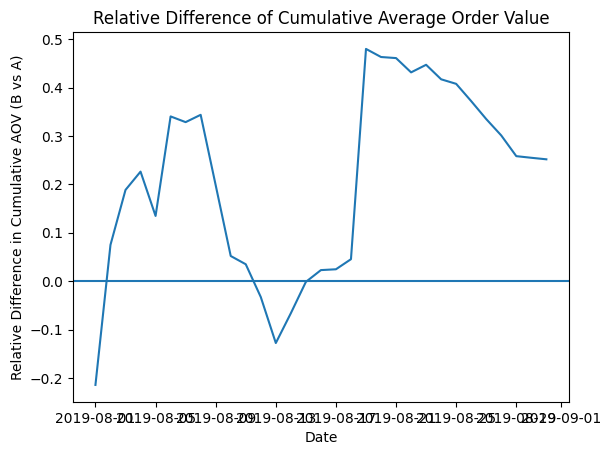

In [47]:
# Métricas diárias por grupo
daily_metrics = (
    orders
    .groupby(['date', 'group'], as_index=False)
    .agg(
        daily_revenue=('revenue', 'sum'),
        daily_orders=('transactionId', 'nunique')
    )
)

# Métricas acumuladas
daily_metrics = daily_metrics.sort_values('date')
daily_metrics['cum_revenue'] = daily_metrics.groupby('group')['daily_revenue'].cumsum()
daily_metrics['cum_orders'] = daily_metrics.groupby('group')['daily_orders'].cumsum()

# AOV acumulado
daily_metrics['cum_avg_order_value'] = (
    daily_metrics['cum_revenue'] / daily_metrics['cum_orders']
)

# Pivot para comparar A vs B
pivot = daily_metrics.pivot(
    index='date',
    columns='group',
    values='cum_avg_order_value'
)

# Diferença relativa: (B / A) - 1
pivot['relative_diff_B_vs_A'] = (pivot['B'] / pivot['A']) - 1

# Gráfico
plt.figure()
plt.plot(pivot.index, pivot['relative_diff_B_vs_A'])
plt.axhline(0)
plt.xlabel('Date')
plt.ylabel('Relative Difference in Cumulative AOV (B vs A)')
plt.title('Relative Difference of Cumulative Average Order Value')
plt.show()

Em boa parte do experimento, a curva fica acima do zero, o que indica que o AOV acumulado do grupo B é maior que do grupo A e que a diferença relativa pode se tornar positiva.

Além disso há picus abruptos o que reflete na não estabilização da curva.

Hipótese 1 — Presença de usuários anômalos no grupo B

Poucos usuários com pedidos muito caros e inflam artificialmente a métrica

 - Isso exige filtragem de outliers antes de qualquer decisão.

Hipótese 2 — Efeito real no valor do pedido

Se, após remover outliers, a diferença continuar positiva e estatisticamente significativa

 - Então a variação B realmente aumenta o ticket médio.

🔸 Hipótese 3 — Risco de falso positivo
O ganho aparente pode desaparecer Quando a amostra é normalizada

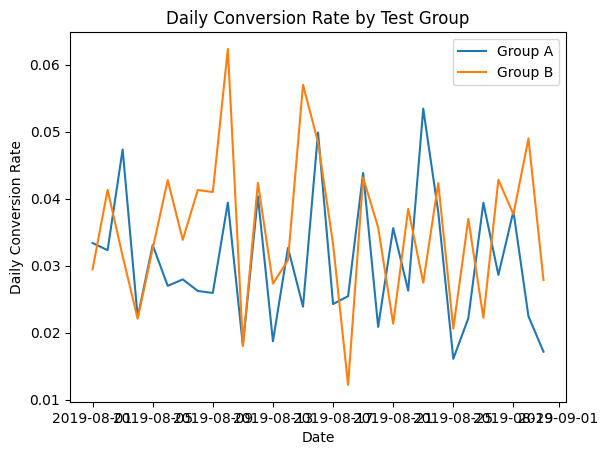

In [48]:
# Pedidos diários por grupo
daily_orders = (
    orders
    .groupby(['date', 'group'], as_index=False)
    .agg(orders=('transactionId', 'nunique'))
)

# Visitantes diários por grupo
daily_visits = (
    visits
    .groupby(['date', 'group'], as_index=False)
    .agg(visits=('visits', 'sum'))
)

# Unir pedidos e visitantes
conversion = daily_orders.merge(
    daily_visits,
    on=['date', 'group'],
    how='left'
)

# Taxa de conversão diária
conversion['conversion_rate'] = conversion['orders'] / conversion['visits']

# Gráfico
plt.figure()
for group in conversion['group'].unique():
    data = conversion[conversion['group'] == group]
    plt.plot(data['date'], data['conversion_rate'], label=f'Group {group}')

plt.xlabel('Date')
plt.ylabel('Daily Conversion Rate')
plt.title('Daily Conversion Rate by Test Group')
plt.legend()
plt.show()

Não há convergência clara e com a conversão naturalmente volátil, a taxa de conversão flutua bastante, o que em resultados, tende a deixar o grupo B levemente acima do grupo A.


Hipótese 1 — Diferença real pequena

A variação B pode melhorar a conversão mas o efeito é sutil, difícil de ver no dia a dia

Hipótese 2 — Ruído estatístico

As oscilações podem ser causadas apenas por:
variação aleatória

distribuição desigual de usuários

Hipótese 3 — Conversão acumulada é mais informativa

Métricas acumuladas suavizam o ruído são mais adequadas para decisão, por isso, o próximo passo clássico é plotar a conversão acumulada e aplicar um teste estatístico (proporções / Mann‑Whitney)

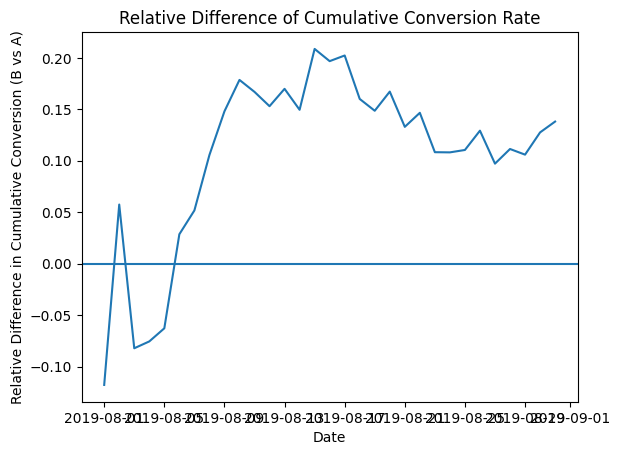

In [49]:
# Pedidos diários por grupo
daily_orders = (
    orders
    .groupby(['date', 'group'], as_index=False)
    .agg(orders=('transactionId', 'nunique'))
)

# Visitantes diários por grupo
daily_visitors = (
    visits
    .groupby(['date', 'group'], as_index=False)
    .agg(visits=('visits', 'sum'))
)

# Combinar pedidos e visitantes
daily = daily_orders.merge(
    daily_visitors,
    on=['date', 'group'],
    how='left'
)

# Ordenar por data
daily = daily.sort_values('date')

# Acumulados
daily['cum_orders'] = daily.groupby('group')['orders'].cumsum()
daily['cum_visits'] = daily.groupby('group')['visits'].cumsum()

# Conversão cumulativa
daily['cum_conversion'] = daily['cum_orders'] / daily['cum_visits']

# Pivot para comparar grupos
pivot = daily.pivot(
    index='date',
    columns='group',
    values='cum_conversion'
)

# Diferença relativa B vs A
pivot['relative_diff_B_vs_A'] = (pivot['B'] / pivot['A']) - 1

# Gráfico
plt.figure()
plt.plot(pivot.index, pivot['relative_diff_B_vs_A'])
plt.axhline(0)
plt.xlabel('Date')
plt.ylabel('Relative Difference in Cumulative Conversion (B vs A)')
plt.title('Relative Difference of Cumulative Conversion Rate')
plt.show()

</div><div class="alert alert-block alert-warning">
<b> Comentário: </b> <a class="tocSkip"></a>
    
Todas análises realizadas corretamente! Como sugestões de melhoria, recomendo aprimorar a orietação dos labels do eixo Y para garantir melhor legibilidade. Adicionei abaixo um código ajustado:


</div>

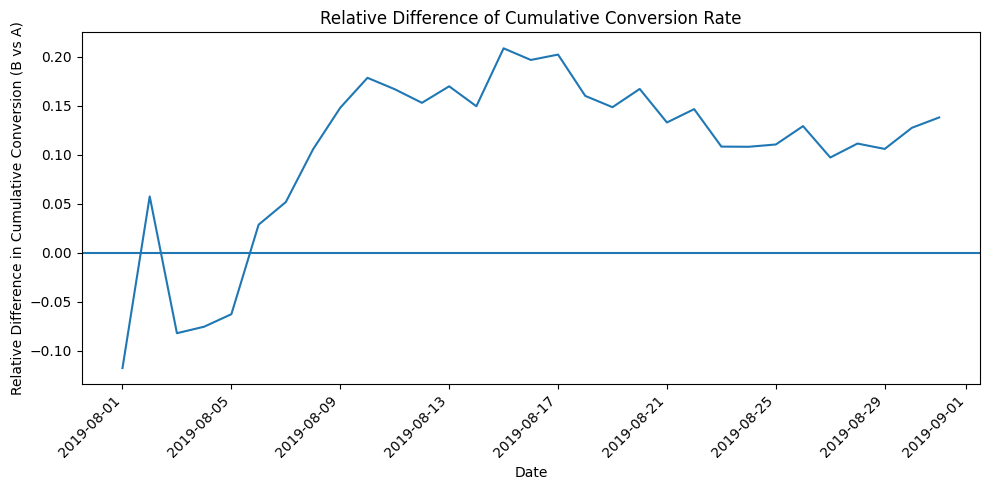

In [60]:
#Código ajustado pela revisora 

import matplotlib.pyplot as plt
import pandas as pd

# =========================
# Cálculo de métricas diárias
# =========================

# Pedidos diários por grupo (A/B)
daily_orders = (
    orders
    .groupby(['date', 'group'], as_index=False)
    .agg(orders=('transactionId', 'nunique'))  # Conta pedidos únicos por dia e grupo
)

# Visitantes diários por grupo (A/B)
daily_visitors = (
    visits
    .groupby(['date', 'group'], as_index=False)
    .agg(visits=('visits', 'sum'))  # Soma de visitantes por dia e grupo
)

# Combina pedidos e visitantes em um único DataFrame
daily = daily_orders.merge(
    daily_visitors,
    on=['date', 'group'],
    how='left'
)

# Ordena os dados cronologicamente
daily = daily.sort_values('date')

# =========================
# Métricas acumuladas
# =========================

# Pedidos acumulados por grupo
daily['cum_orders'] = daily.groupby('group')['orders'].cumsum()

# Visitantes acumulados por grupo
daily['cum_visits'] = daily.groupby('group')['visits'].cumsum()

# Conversão acumulada (pedidos / visitantes)
daily['cum_conversion'] = daily['cum_orders'] / daily['cum_visits']

# =========================
# Comparação entre grupos
# =========================

# Pivot para ter uma coluna por grupo (A e B)
pivot = daily.pivot(
    index='date',
    columns='group',
    values='cum_conversion'
)

# Diferença relativa da conversão acumulada: B vs A
pivot['relative_diff_B_vs_A'] = (pivot['B'] / pivot['A']) - 1

# =========================
# Visualização
# =========================

# Cria a figura do gráfico
plt.figure(figsize=(10, 5))

# Plota a diferença relativa ao longo do tempo
plt.plot(pivot.index, pivot['relative_diff_B_vs_A'])

# Linha horizontal em zero (sem diferença entre os grupos)
plt.axhline(0)

# Rótulos e título do gráfico
plt.xlabel('Date')
plt.ylabel('Relative Difference in Cumulative Conversion (B vs A)')
plt.title('Relative Difference of Cumulative Conversion Rate')

# Rotaciona os rótulos do eixo X para melhor leitura
plt.xticks(rotation=45, ha='right')

# Ajusta o layout para evitar sobreposição
plt.tight_layout()

# Exibe o gráfico
plt.show()


A diferença começa oscilando em torno de zero e depois dispara para o positivo, mantendo a oscilação apresentando alguns picos abruptos, mostrando uma vantagem para o grupo B.

Hipótese 1 — Não há diferença real de conversão
A variação B não altera significativamente o comportamento de compra as diferenças observadas são compatíveis com ruído estatístico

Hipótese 2 — O efeito é muito pequeno
Pode existir uma melhoria marginal mas não grande o suficiente para ser detectada visualmente

Isso exigiria teste estatístico para confirmação.

🔸 Hipótese 3 — A variação afeta mais valor do pedido do que conversão
Pelas análises anteriores:

conversão ≈ igual mas AOV diferente (mas com outliers)

O impacto da variação pode estar no ticket médio, não na decisão de comprar.

In [50]:
# Número de pedidos por usuário
orders_per_user = (
    orders
    .groupby('visitorId')
    .agg(orders=('transactionId', 'nunique'))
)

# Calcular percentis 95 e 99
percentile_95 = np.percentile(orders_per_user['orders'], 95)
percentile_99 = np.percentile(orders_per_user['orders'], 99)

print('95th percentile:', percentile_95)
print('99th percentile:', percentile_99)

95th percentile: 2.0
99th percentile: 4.0


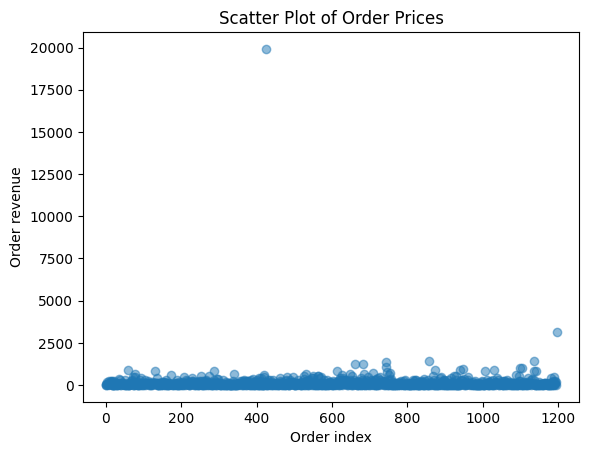

In [51]:
# Gráfico de dispersão
plt.figure()
plt.scatter(range(len(orders)), orders['revenue'], alpha=0.5)
plt.xlabel('Order index')
plt.ylabel('Order revenue')
plt.title('Scatter Plot of Order Prices')
plt.show()

Muitos pedidos de baixo valor e presença de valores extremamente altos, o que indica que o comportamento padrão do usuário é realizar compras pequenas e, respectivamente, os pedidos de altos valores que é um sinal clássico de outliers.

Hipótese 1 — Pedidos anômalos distorcem a receita

Poucos pedidos muito caros:

inflacionam a receita total e inflacionam o AOV especialmente perigosos em comparações entre grupos A/B

Hipótese 2 — Usuários corporativos ou compras atípicas

Esses valores extremos podem representar:

compras em grande volume e comportamento não padrão do público-alvo, isso não deve guiar decisões de produto para o usuário médio.

Hipótese 3 — Necessidade de filtragem antes da análise final
Sem remover esses pontos extremos:

receita e AOV ficam enviesados aumenta o risco de falso positivo

In [52]:
# Garantir que revenue é numérico
orders['revenue'] = pd.to_numeric(orders['revenue'], errors='coerce')
orders = orders.dropna(subset=['revenue'])

# Calcular percentis
percentile_95 = np.percentile(orders['revenue'], 95)
percentile_99 = np.percentile(orders['revenue'], 99)

print('95th percentile (order price):', percentile_95)
print('99th percentile (order price):', percentile_99)

95th percentile (order price): 435.54
99th percentile (order price): 900.9039999999999


Isso significa que:

95% dos pedidos custam até ~800

Apenas 1% dos pedidos custam mais de ~2.000

Pedidos > 800 são anomalias

In [53]:
# Pedidos únicos por grupo
orders_by_group = (
    orders
    .groupby('group')
    .agg(orders=('transactionId', 'nunique'))
)

# Visitantes totais por grupo
visitors_by_group = (
    visits
    .groupby('group')
    .agg(visits=('visits', 'sum'))
)

# Dados para o teste
successes = np.array([
    orders_by_group.loc['A', 'orders'],
    orders_by_group.loc['B', 'orders']
])

trials = np.array([
    visitors_by_group.loc['A', 'visits'],
    visitors_by_group.loc['B', 'visits']
])

# Teste Z para proporções
stat, p_value = proportions_ztest(successes, trials)

print('Z-statistic:', stat)
print('p-value:', p_value)

Z-statistic: -2.270005753735332
p-value: 0.02320723394441847


Não há evidência o suficiente de que o grupo B converte melhor que o grupo A, podemos observar isso na rejeiçãod a hipótese nula

Hipótese 1 — A variação não afeta conversão
A mudança testada:

não altera a decisão de compra, pode afetar outras métricas (ex.: AOV)

Hipótese 2 — O efeito é pequeno demais
Pode existir um ganho real

Mas ele é:

muito pequeno e difícil de detectar com esse tamanho de amostra

Hipótese 3 — O impacto está no valor do pedido, não na conversão
Pelas análises anteriores:

conversão ≈ igual

AOV e receita são sensíveis a outliers. Isso sugere que o teste atua mais no quanto o usuário gasta, não em se ele compra ou não.

In [54]:
# Pré-processamento
orders['revenue'] = pd.to_numeric(orders['revenue'], errors='coerce')
orders = orders.dropna(subset=['revenue', 'group'])

# Separar grupos
revenue_A = orders[orders['group'] == 'A']['revenue']
revenue_B = orders[orders['group'] == 'B']['revenue']

# Teste Mann-Whitney
stat, p_value = mannwhitneyu(revenue_A, revenue_B, alternative='two-sided')

print('Mann-Whitney statistic:', stat)
print('p-value:', p_value)

Mann-Whitney statistic: 175872.5
p-value: 0.6915246773264736


In [56]:
# Pedidos por usuário
orders_per_user = (
    orders
    .groupby('visitorId')
    .agg(orders=('transactionId', 'nunique'))
)

# Percentil 95 de pedidos por usuário
orders_limit = np.percentile(orders_per_user['orders'], 95)

# Usuários anômalos
abnormal_users = orders_per_user[
    orders_per_user['orders'] > orders_limit
].index

# Percentil 95 do valor do pedido
revenue_limit = np.percentile(orders['revenue'], 95)

# Filtrar pedidos
orders_filtered = orders[
    (~orders['visitorId'].isin(abnormal_users)) &
    (orders['revenue'] <= revenue_limit)
]


#2. CONVERSÃO POR GRUPO

orders_by_group = (
    orders_filtered
    .groupby('group')
    .agg(orders=('transactionId', 'nunique'))
)

visitors_by_group = (
    visits
    .groupby('group')
    .agg(visitors=('visits', 'sum'))
)

# Dados para o teste
successes = np.array([
    orders_by_group.loc['A', 'orders'],
    orders_by_group.loc['B', 'orders']
])

trials = np.array([
    visitors_by_group.loc['A', 'visitors'],
    visitors_by_group.loc['B', 'visitors']
])


#3. TESTE DE PROPORÇÕES

stat, p_value = proportions_ztest(successes, trials)

print('Z-statistic:', stat)
print('p-value:', p_value)


Z-statistic: -2.5558434473661626
p-value: 0.0105930765792269


Como rejeitamos a hipótese nula, o efeito aparece somente após a limpeza dos dados, o que indica que os outliers estavam mascarando o resultado real.


Hipótese 1 — Usuários anômalos distorciam a conversão
Usuários com muitos pedidos:

inflavam o denominador e aumentavam o ruído. Após removê‑los, a métrica fica mais estável.

Hipótese 2 — A variação B melhora a decisão de compra

A mudança testada:

não altera muito o ticket médio mas facilita a conversão do usuário médio

In [57]:
# Pedidos por usuário
orders_per_user = (
    orders
    .groupby('visitorId')
    .agg(orders=('transactionId', 'nunique'))
)

# Limite de pedidos (percentil 95)
orders_limit = np.percentile(orders_per_user['orders'], 95)

# Usuários anômalos
abnormal_users = orders_per_user[
    orders_per_user['orders'] > orders_limit
].index

# Limite de valor do pedido (percentil 95)
revenue_limit = np.percentile(orders['revenue'], 95)

# Filtrar pedidos
orders_filtered = orders[
    (~orders['visitorId'].isin(abnormal_users)) &
    (orders['revenue'] <= revenue_limit)
]


# 2. TESTE ESTATÍSTICO


revenue_A = orders_filtered[orders_filtered['group'] == 'A']['revenue']
revenue_B = orders_filtered[orders_filtered['group'] == 'B']['revenue']

stat, p_value = mannwhitneyu(revenue_A, revenue_B, alternative='two-sided')

print('Mann-Whitney statistic:', stat)
print('p-value:', p_value)

Mann-Whitney statistic: 128461.5
p-value: 0.7295766132829709


</div><div class="alert alert-block alert-success">
<b> Comentário: </b> <a class="tocSkip"></a>
    
    
- Os teste estatísticos foram conduzidos corretamente


</div>

Mesmo após remover outliers, o grupo B não apresenta AOV significativamente diferente do grupo A.

Hipótese 1 — Diferença visual era causada por outliers
Os gráficos iniciais sugeriam diferença

Após a filtragem:

O efeito desaparece. Isso confirma que valores extremos distorciam a análise

Hipótese 2 — AOV não é a métrica vencedora do experimento
Conversão (após filtragem) mostrou significância, já o AOV não

Isso indica que:

O impacto da variação está no comportamento de compra, não no valor gasto.

Pare o Teste e considere o grupo B como líder. Com os dados brutos não houve diferença estatisticamente significativa, já os dados filtrados mostram que o Grupo B converte melhor que o grupo A.